In [ ]:
%pip install -r requirements.txt

In [1]:
import pandas as pd

In [10]:
df = pd.read_csv('Mobile Reviews Sentiment null.csv')

In [11]:
df

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,A$804.93,AUD,1.53,4.0,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,A$1395.13,AUD,1.53,3.0,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,د.إ4240.02,AED,3.67,NaN,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,NaN,USD,1.00,3.0,...,English,7/11/2025,True,1,2,2,1,3,6,NaN


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  str    
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  str    
 4   model                 50000 non-null  str    
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  str    
 7   currency              50000 non-null  str    
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  str    
 11  country               50000 non-null  str    
 12  language              50000 non-null  str    
 13  review_date           50000 non-null  str    
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating   50000 no

In [13]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['price_usd'] = df.groupby('model')['price_usd'].transform(lambda x: x.fillna(x.mean()))

In [16]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd                  0
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [17]:
df['rating'] = df.groupby(['model', 'display_rating','performance_rating'])['rating'].transform(lambda x: x.fillna(x.mean()))

In [18]:
df['sentiment'] = df.groupby(['model','performance_rating'])['sentiment'].transform(lambda x: x.fillna(x.mode()[0]))

In [19]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd                  0
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [20]:
df['source'] = df.groupby(['brand','model'])['source'].transform(lambda x: x.fillna(x.mode()[0]))

In [21]:
df.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd                  0
price_local             2431
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64

In [22]:
df.drop(columns=['review_id','price_local','review_date','customer_name','exchange_rate_to_usd'], inplace=True)

In [23]:
df.isnull().sum()

age                    0
brand                  0
model                  0
price_usd              0
currency               0
rating                 0
sentiment              0
country                0
language               0
verified_purchase      0
battery_life_rating    0
camera_rating          0
performance_rating     0
design_rating          0
display_rating         0
helpful_votes          0
source                 0
dtype: int64

In [24]:
df.to_csv('Mobile Reviews Sentiment.csv', index=False)

In [2]:
df =pd.read_csv('Mobile Reviews Sentiment.csv')
df

,age,brand,model,price_usd,currency,rating,sentiment,country,language,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,45,Realme,Realme 12 Pro,337.31,INR,2.000000,Negative,India,Hindi,True,1,1,3,2,1,1,Amazon
1,18,Realme,Realme 12 Pro,307.78,BRL,4.000000,Positive,Brazil,Portuguese,True,3,2,4,3,2,5,Flipkart
2,27,Google,Pixel 6,864.53,INR,4.000000,Positive,India,Hindi,True,3,5,3,2,4,8,AliExpress
3,19,Xiaomi,Redmi Note 13,660.94,AED,3.000000,Positive,UAE,English,False,1,3,2,1,2,3,Amazon
4,38,Motorola,Edge 50,792.13,BRL,3.000000,Neutral,Brazil,Portuguese,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,18,Realme,Realme 12 Pro,526.10,AUD,4.000000,Positive,Australia,English,False,3,3,4,3,5,4,BestBuy
49996,28,Samsung,Galaxy Note 20,911.85,AUD,3.000000,Neutral,Australia,English,False,3,2,4,1,3,2,AliExpress
49997,21,Apple,iPhone SE,1155.32,AED,4.555556,Positive,UAE,English,True,2,3,4,4,5,4,Amazon
49998,31,Realme,Realme Narzo 70,459.04,USD,3.000000,Positive,USA,English,True,1,2,2,1,3,6,eBay


In [26]:
df.shape

(50000, 17)

In [30]:
df.describe()

,age,price_usd,rating,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,30.075220,689.797025,3.122950,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180
std,8.931307,307.332390,1.241403,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745
min,18.000000,180.020000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,23.000000,450.427500,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,29.000000,640.805000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,36.000000,899.215000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000
max,65.000000,1499.890000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,17.000000


In [3]:
brand_total_sales =df.groupby(['brand','model'])['price_usd'].mean().sort_values(ascending=False)
print(brand_total_sales)

brand     model          
Apple     iPhone 13          1106.216589
          iPhone SE          1103.598758
          iPhone 14          1102.027704
          iPhone 15 Pro      1100.782200
Samsung   Galaxy A55          906.946676
          Galaxy Note 20      900.871253
          Galaxy Z Flip       898.912823
          Galaxy S24          895.131099
Google    Pixel 6             808.631768
          Pixel 7a            807.655334
          Pixel 8             799.029890
OnePlus   OnePlus Nord 3      673.148079
          OnePlus 11R         673.023320
          OnePlus 12          670.238523
Motorola  Edge 50             509.784546
          Razr 40             505.917338
          Moto G Power        503.959511
Xiaomi    Poco X6             450.490536
          Redmi Note 13       449.615434
          Mi 13 Pro           449.180155
Realme    Realme 12 Pro       394.327411
          Realme Narzo 70     392.155240
Name: price_usd, dtype: float64


In [3]:
import plotly.express as px
import plotly.io as pio 
pio.renderers.default="png"

In [4]:
brand_wise_model_sales = df.groupby('brand')['model'].value_counts().reset_index(name='model_count')
print(brand_wise_model_sales)

       brand            model  model_count
0      Apple        iPhone SE         1796
1      Apple    iPhone 15 Pro         1793
2      Apple        iPhone 14         1788
3      Apple        iPhone 13         1767
4     Google         Pixel 7a         2468
5     Google          Pixel 8         2387
6     Google          Pixel 6         2379
7   Motorola          Razr 40         2395
8   Motorola     Moto G Power         2351
9   Motorola          Edge 50         2315
10   OnePlus      OnePlus 11R         2433
11   OnePlus   OnePlus Nord 3         2380
12   OnePlus       OnePlus 12         2323
13    Realme  Realme Narzo 70         3597
14    Realme    Realme 12 Pro         3535
15   Samsung   Galaxy Note 20         1789
16   Samsung       Galaxy A55         1788
17   Samsung       Galaxy S24         1761
18   Samsung    Galaxy Z Flip         1714
19    Xiaomi    Redmi Note 13         2470
20    Xiaomi        Mi 13 Pro         2445
21    Xiaomi          Poco X6         2326


In [5]:
top_10_df = (
    df.groupby('brand')['model'].value_counts().sort_values(ascending=False).head(10).reset_index()
)
print(top_10_df)

      brand            model  count
0    Realme  Realme Narzo 70   3597
1    Realme    Realme 12 Pro   3535
2    Xiaomi    Redmi Note 13   2470
3    Google         Pixel 7a   2468
4    Xiaomi        Mi 13 Pro   2445
5   OnePlus      OnePlus 11R   2433
6  Motorola          Razr 40   2395
7    Google          Pixel 8   2387
8   OnePlus   OnePlus Nord 3   2380
9    Google          Pixel 6   2379


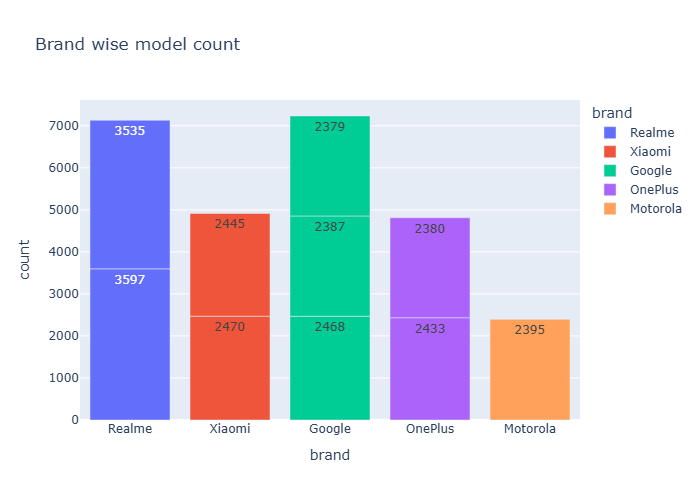

In [6]:
fig = px.bar(top_10_df,x='brand',y='count',title='Brand wise model count',color='brand',text='count')
fig.show()

In [7]:
top_10_models =(
    df.groupby(['model','brand'])['price_usd'].mean().sort_values(ascending=False).head(10)
      .reset_index()
)
print(top_10_models)

            model    brand    price_usd
0       iPhone 13    Apple  1106.216589
1       iPhone SE    Apple  1103.598758
2       iPhone 14    Apple  1102.027704
3   iPhone 15 Pro    Apple  1100.782200
4      Galaxy A55  Samsung   906.946676
5  Galaxy Note 20  Samsung   900.871253
6   Galaxy Z Flip  Samsung   898.912823
7      Galaxy S24  Samsung   895.131099
8         Pixel 6   Google   808.631768
9        Pixel 7a   Google   807.655334


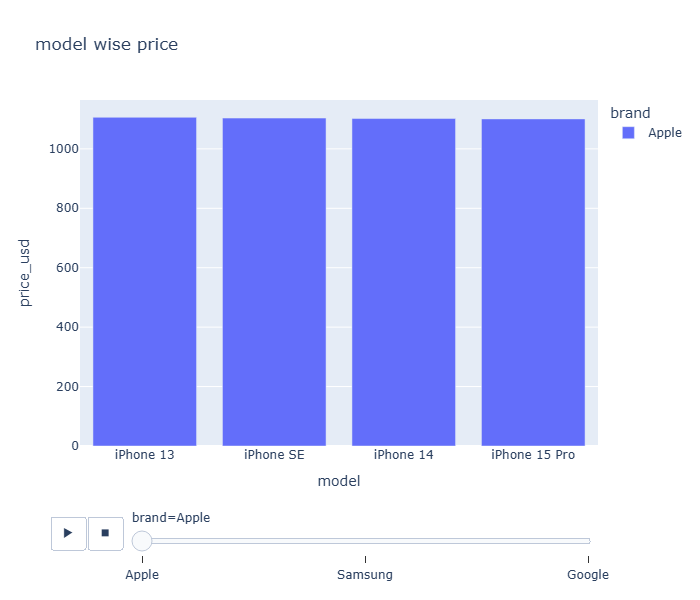

In [8]:
fig = px.bar(top_10_models,
             x='model',
             y='price_usd',
             color='brand',
               animation_frame='brand',
               animation_group='model',
               title='model wise price')

fig.update_layout(height=600)
fig.show()

In [9]:
model_wise_display_ratig=(
    df.groupby('model')['display_rating'].value_counts().sort_values(ascending=False).head(10).
    reset_index()
)
print(model_wise_display_ratig)

             model  display_rating  count
0  Realme Narzo 70               1    902
1    Realme 12 Pro               1    864
2    Realme 12 Pro               3    806
3  Realme Narzo 70               3    790
4  Realme Narzo 70               2    767
5    Realme 12 Pro               2    730
6    Realme 12 Pro               4    666
7  Realme Narzo 70               4    663
8      OnePlus 11R               1    633
9        Mi 13 Pro               1    631


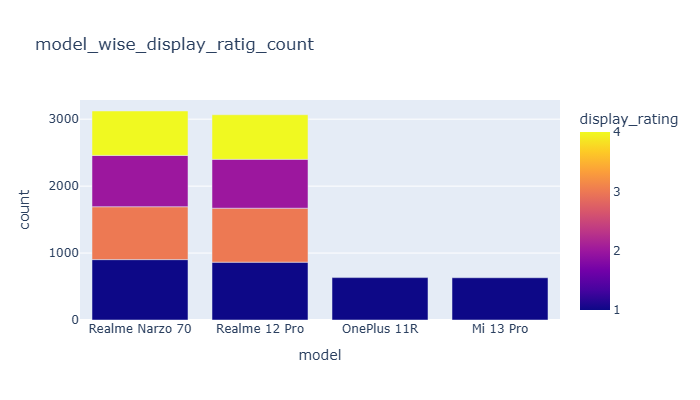

In [10]:
fig=px.bar(
    model_wise_display_ratig,
    x='model',
    y='count',
    color='display_rating',
    barmode="group",
    title='model_wise_display_ratig_count'
)
fig.update_layout(height=400)
fig.show()

In [11]:
brand_prices_df=(
    df.groupby(['brand','model'])['price_usd']
    .mean()
    .reset_index()
    .sort_values(by='price_usd',ascending=False)

)
print(brand_prices_df)

       brand            model    price_usd
0      Apple        iPhone 13  1106.216589
3      Apple        iPhone SE  1103.598758
1      Apple        iPhone 14  1102.027704
2      Apple    iPhone 15 Pro  1100.782200
15   Samsung       Galaxy A55   906.946676
16   Samsung   Galaxy Note 20   900.871253
18   Samsung    Galaxy Z Flip   898.912823
17   Samsung       Galaxy S24   895.131099
4     Google          Pixel 6   808.631768
5     Google         Pixel 7a   807.655334
6     Google          Pixel 8   799.029890
12   OnePlus   OnePlus Nord 3   673.148079
10   OnePlus      OnePlus 11R   673.023320
11   OnePlus       OnePlus 12   670.238523
7   Motorola          Edge 50   509.784546
9   Motorola          Razr 40   505.917338
8   Motorola     Moto G Power   503.959511
20    Xiaomi          Poco X6   450.490536
21    Xiaomi    Redmi Note 13   449.615434
19    Xiaomi        Mi 13 Pro   449.180155
13    Realme    Realme 12 Pro   394.327411
14    Realme  Realme Narzo 70   392.155240


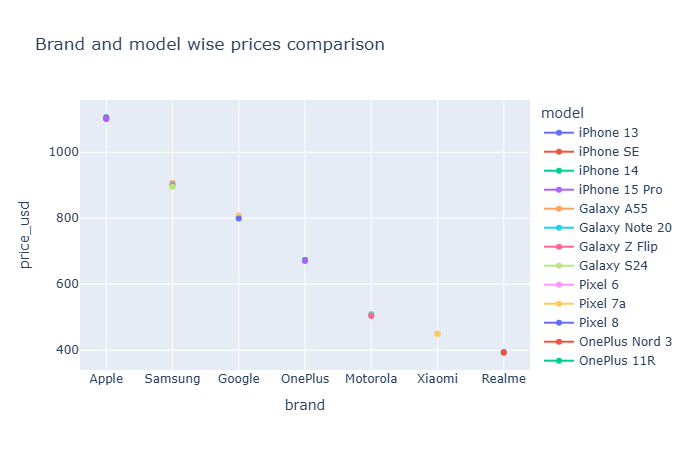

In [12]:
fig=px.line(
    brand_prices_df,
    x='brand',
    y='price_usd',
    color='model',
    markers=True,
    title='Brand and model wise prices comparison',

)
fig.update_layout(height=450)
fig.show()

In [9]:
df.groupby('model')['price_usd'].mean().sort_values(ascending=False).head(10).reset_index()

,model,price_usd
0,iPhone 13,1106.216589
1,iPhone SE,1103.598758
2,iPhone 14,1102.027704
3,iPhone 15 Pro,1100.782200
4,Galaxy A55,906.946676
5,Galaxy Note 20,900.871253
6,Galaxy Z Flip,898.912823
7,Galaxy S24,895.131099
8,Pixel 6,808.631768
9,Pixel 7a,807.655334


In [8]:
df.groupby('currency')['price_usd'].sum().sort_values(ascending=False).head(10).reset_index()

,currency,price_usd
0,BRL,4.444434e+06
1,USD,4.412352e+06
2,AED,4.308944e+06
3,EUR,4.294152e+06
4,AUD,4.288490e+06
5,GBP,4.266810e+06
6,CAD,4.255873e+06
7,INR,4.218796e+06


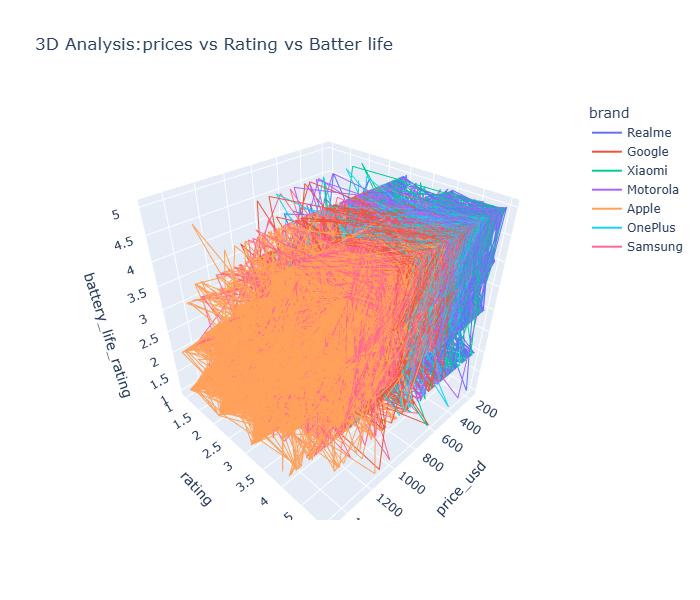

In [13]:
fig = px.line_3d(
    df,
    x='price_usd',
    y='rating',
    z='battery_life_rating',
    color='brand',
    hover_name='model',
    title=" 3D Analysis:prices vs Rating vs Batter life "

) 
fig.update_layout(height=600)
fig.show()

In [14]:
#age wise brand and model using
bins = [18,25,35,50,100]
labels = ['18-24','25-34','35-49','50+']
df['age_group'] = pd.cut(df['age'],bins=bins,labels=labels,right=False)

age_model_df=(
    df.groupby(['age_group','model','brand'])
    .size()
    .reset_index(name='user_count')
)

print(age_model_df)

   age_group           model     brand  user_count
0      18-24         Edge 50  Motorola         690
1      18-24      Galaxy A55   Samsung         543
2      18-24  Galaxy Note 20   Samsung         539
3      18-24      Galaxy S24   Samsung         529
4      18-24   Galaxy Z Flip   Samsung         505
..       ...             ...       ...         ...
83       50+   Redmi Note 13    Xiaomi          51
84       50+       iPhone 13     Apple          43
85       50+       iPhone 14     Apple          36
86       50+   iPhone 15 Pro     Apple          41
87       50+       iPhone SE     Apple          53

[88 rows x 4 columns]


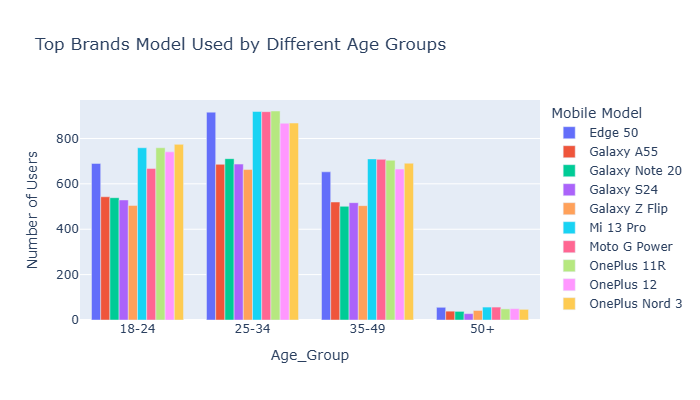

In [15]:
top_models_per_age = age_model_df.groupby('age_group').head(10)

fig = px.bar(
    top_models_per_age,
    x='age_group',
    y='user_count',
    color='model',
    barmode='group',
    title='Top Brands Model Used by Different Age Groups',
    labels={
        'age_group':'Age_Group',
        'user_count':'Number of Users',
        'model':'Mobile Model'

    }
)
fig.update_layout(height=400)
fig.show()


In [16]:
top_source = df.groupby('source')['model'].value_counts().sort_values(ascending=False).head(10).reset_index()

print(top_source)

       source            model  count
0      Amazon    Realme 12 Pro    877
1        eBay  Realme Narzo 70    866
2    Flipkart  Realme Narzo 70    704
3  AliExpress  Realme Narzo 70    701
4        eBay    Realme 12 Pro    692
5     BestBuy  Realme Narzo 70    676
6     BestBuy    Realme 12 Pro    674
7    Flipkart    Realme 12 Pro    672
8      Amazon  Realme Narzo 70    650
9  AliExpress    Redmi Note 13    641


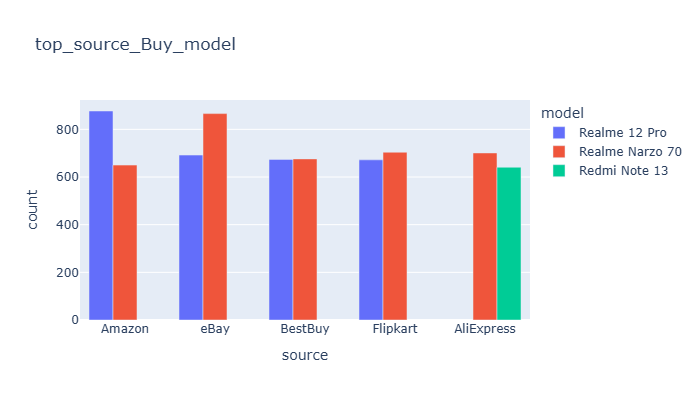

In [17]:
fig=px.bar(
    top_source,
    x='source',
    y='count',
    color='model',
    barmode="group",
    title='top_source_Buy_model'
)
fig.update_layout(height=400)
fig.show()

In [18]:
df.groupby(['model','rating'])['price_usd'].sum().sort_values(ascending=False).head(10).reset_index()

,model,rating,price_usd
0,iPhone 15 Pro,4.0,552957.842800
1,Pixel 6,4.0,532671.784802
2,Pixel 7a,4.0,530187.650034
3,iPhone 13,4.0,522217.641557
4,Pixel 8,4.0,517092.406275
5,iPhone 14,4.0,515087.111777
6,iPhone SE,3.0,496027.827644
7,iPhone SE,4.0,483930.406402
8,iPhone 14,3.0,474980.051777
9,OnePlus Nord 3,4.0,470794.294691


In [19]:
total_reviews = df['rating'].sum()
print(total_reviews)

156147.4938014631


In [20]:
brand_share =(
    df.groupby('brand')['rating'].sum()/total_reviews
)*100

brand_share = brand_share.reset_index().sort_values(
    by='rating',ascending=False
)
brand_share.columns=['brand','estimated_sales_percentage']
print(brand_share)

      brand  estimated_sales_percentage
1    Google                   14.464489
6    Xiaomi                   14.447250
0     Apple                   14.330225
4    Realme                   14.327653
3   OnePlus                   14.295214
2  Motorola                   14.067731
5   Samsung                   14.067437


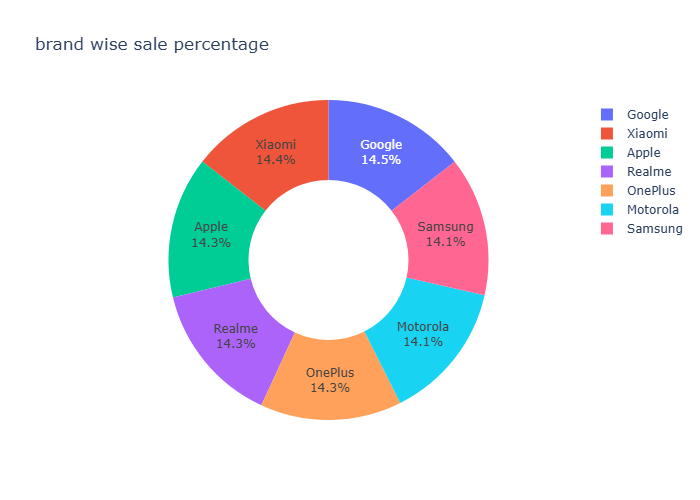

In [21]:
fig =px.pie(
  brand_share,
  names='brand',
  values='estimated_sales_percentage',
  title='brand wise sale percentage',
  hole=0.5
 )
fig.update_traces(textinfo="percent+label")
fig.show()

In [28]:
df['brand'].unique()

<ArrowStringArray>
['Realme', 'Google', 'Xiaomi', 'Motorola', 'Apple', 'OnePlus', 'Samsung']
Length: 7, dtype: str

In [27]:
df['model'].unique()

<ArrowStringArray>
[  'Realme 12 Pro',         'Pixel 6',   'Redmi Note 13',         'Edge 50',
       'iPhone 14',      'OnePlus 12',       'iPhone SE',  'OnePlus Nord 3',
       'Mi 13 Pro',    'Moto G Power', 'Realme Narzo 70',  'Galaxy Note 20',
        'Pixel 7a',         'Razr 40',         'Poco X6',   'iPhone 15 Pro',
         'Pixel 8',       'iPhone 13',      'Galaxy S24',      'Galaxy A55',
     'OnePlus 11R',   'Galaxy Z Flip']
Length: 22, dtype: str

In [4]:
df['currency'].unique()

<ArrowStringArray>
['INR', 'BRL', 'AED', 'AUD', 'EUR', 'GBP', 'CAD', 'USD']
Length: 8, dtype: str

In [5]:
df['sentiment'].unique()

<ArrowStringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str

In [6]:
df['language'].unique()

<ArrowStringArray>
['Hindi', 'Portuguese', 'English', 'German']
Length: 4, dtype: str

In [9]:
df['verified_purchase'].unique()

array([ True, False])

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

In [23]:
# encoding part
binary_cols = ['verified_purchase'] # binary(true\false)
ordinal_cols = ['sentiment']
ohe_cols =[
    'brand',
    'currency',
    'language',
    'country',
    'source'
]

#scaling
num_cols =['age','price_usd','rating','battery_life_rating','camera_rating','performance_rating','design_rating',
           'display_rating','helpful_votes']

In [24]:
# ordinal & binary line
sentiment_order =['Negative','Neutral','Positive']
binary_order = ['False','True']

In [25]:
for col in ohe_cols+ordinal_cols+binary_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [26]:
# all in one columnstransformer
preprocessor = ColumnTransformer(
    transformers=[(
        "num",StandardScaler(),
        num_cols),
        ("binary",OrdinalEncoder(categories=[binary_order]),
         binary_cols),
         (
             "ordinal",OrdinalEncoder(categories=[sentiment_order]),
             ordinal_cols,
         ),
         (
             "ohe",OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False),ohe_cols,
         ),
        ]
)

In [27]:
x_processed = preprocessor.fit_transform(df)

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [29]:
inertia_value =[]

for i in range(1,7):
    model = KMeans(n_clusters=i)
    model.fit(x_processed)
    inertia_value.append(model.inertia_)

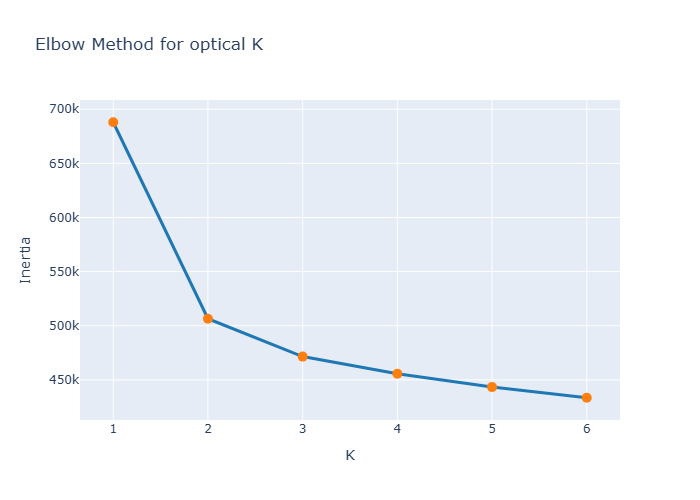

In [30]:
elbow_df = pd.DataFrame({"K": list(range(1,7)), "Inertia": inertia_value})

fig = px.line(
    elbow_df,
    x="K",
    y="Inertia",
    markers=True,
    title="Elbow Method for optical K",
    labels={"k": "Number of clusters(k)", "intertia": 'intertia (WCSS)'},
)
fig.update_traces(line=dict(color="#1f77b4",width=3), marker=dict(size=10,color="#ff7f0e"))
fig.show()

In [31]:
silhouette_value =[]

for i in range(2,7):
      model = KMeans(n_clusters=i)
      model.fit(x_processed)
      score =silhouette_score(x_processed,model.labels_)
      silhouette_value.append(score)
print(silhouette_value)

[0.2237231852974473, 0.12456342121076716, 0.11669450193859822, 0.08805905666242721, 0.07833242728355697]


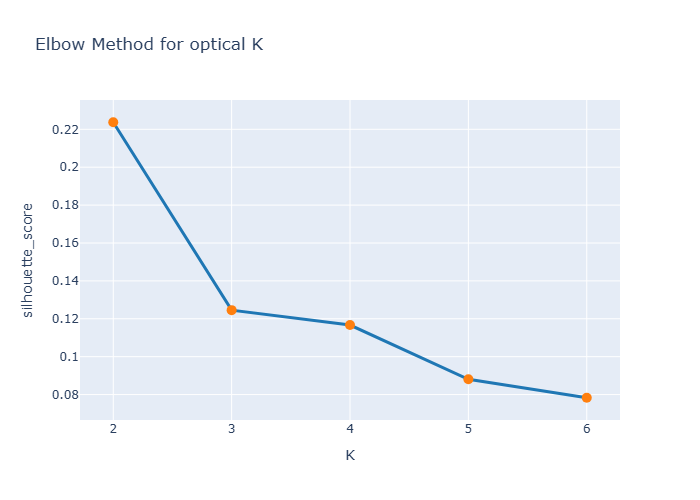

In [32]:
silhouette_df = pd.DataFrame({"K": list(range(2,7)), "silhouette_score": silhouette_value})

fig = px.line(
    silhouette_df,
    x="K",
    y="silhouette_score",
    markers=True,
    title="Elbow Method for optical K",
    labels={"k": "Number of clusters(k)", "silhouette_score": "silhouette_score"},
)
fig.update_traces(line=dict(color="#1f77b4",width=3), marker=dict(size=10,color="#ff7f0e"))
fig.show()

In [33]:
final_Kmeans = KMeans(n_clusters=2)
df["cluster"] = final_Kmeans.fit_predict(x_processed)

print(df["cluster"].value_counts())

cluster
1    26259
0    23741
Name: count, dtype: int64


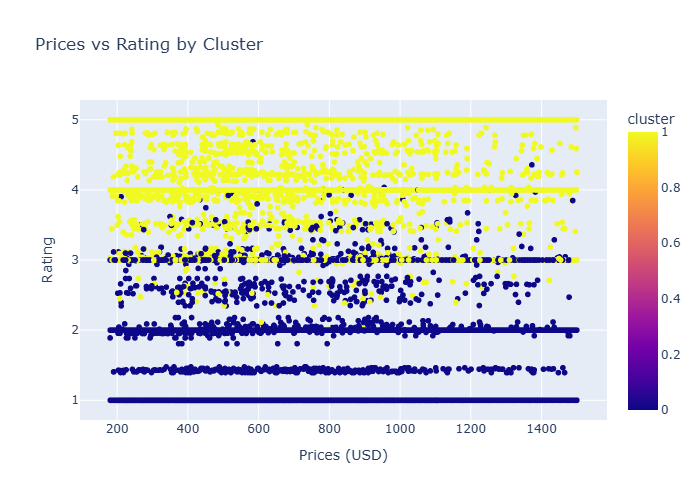

In [34]:
fig = px.scatter(
    df,
    x="price_usd",
    y="rating",
    color="cluster",
    hover_data=["model","brand","country"],
    title="Prices vs Rating by Cluster",
    labels={"price_usd":"Prices (USD)",
            "rating":"Rating"},

)
fig.show()

In [35]:
#check mean value after cluster

cluster_summary = df.groupby("cluster").mean(numeric_only=True)

cluster_summary.T

cluster,0,1
age,30.012299,30.132107
price_usd,690.258305,689.379978
rating,2.062097,4.082077
battery_life_rating,1.736995,3.604935
camera_rating,1.740702,3.600899
performance_rating,1.739312,3.605926
design_rating,1.746978,3.588217
display_rating,1.741755,3.606878
helpful_votes,2.333853,4.828859


In [36]:
df.head(10)

,age,brand,model,price_usd,currency,rating,sentiment,country,language,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,age_group,cluster
0,45,Realme,Realme 12 Pro,337.31,Inr,2.0,Negative,India,Hindi,True,1,1,3,2,1,1,Amazon,35-49,0
1,18,Realme,Realme 12 Pro,307.78,Brl,4.0,Positive,Brazil,Portuguese,True,3,2,4,3,2,5,Flipkart,18-24,1
2,27,Google,Pixel 6,864.53,Inr,4.0,Positive,India,Hindi,True,3,5,3,2,4,8,Aliexpress,25-34,1
3,19,Xiaomi,Redmi Note 13,660.94,Aed,3.0,Positive,Uae,English,False,1,3,2,1,2,3,Amazon,18-24,0
4,38,Motorola,Edge 50,792.13,Brl,3.0,Neutral,Brazil,Portuguese,True,3,3,2,2,1,0,Bestbuy,35-49,0
5,38,Apple,iPhone 14,948.79,Brl,5.0,Positive,Brazil,Portuguese,False,5,4,5,5,4,6,Aliexpress,35-49,1
6,40,Oneplus,OnePlus 12,420.13,Aed,3.0,Positive,Uae,English,False,3,3,2,1,2,2,Ebay,35-49,0
7,39,Apple,iPhone SE,1443.76,Aud,2.0,Negative,Australia,English,True,2,1,2,2,2,3,Amazon,35-49,0
8,32,Realme,Realme 12 Pro,275.73,Eur,4.0,Positive,Germany,German,False,4,3,2,3,3,8,Ebay,25-34,1
9,31,Oneplus,OnePlus Nord 3,545.57,Aud,3.0,Positive,Australia,English,True,2,2,3,3,2,4,Bestbuy,25-34,0


In [37]:
brand_cluster = pd.crosstab(df["brand"],df["cluster"])
print(brand_cluster)

cluster      0     1
brand               
Apple     3387  3757
Google    3422  3812
Motorola  3404  3657
Oneplus   3336  3800
Realme    3328  3804
Samsung   3402  3650
Xiaomi    3462  3779


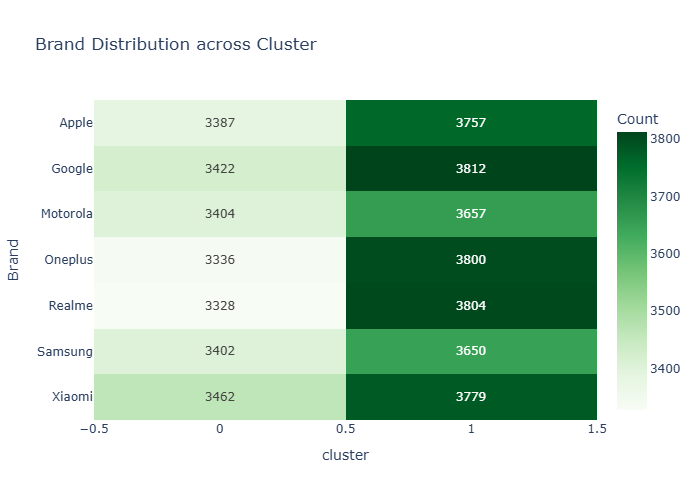

In [38]:
fig = px.imshow(
    brand_cluster,
    text_auto=True,
    color_continuous_scale="Greens",
    labels=dict(x="cluster",
                y='Brand',
                color='Count'),
    title="Brand Distribution across Cluster",
)
fig.show()

In [40]:
model_clusters = pd.crosstab(df["model"],df["cluster"])
print(model_clusters)

cluster             0     1
model                      
Edge 50          1138  1177
Galaxy A55        870   918
Galaxy Note 20    852   937
Galaxy S24        881   880
Galaxy Z Flip     799   915
Mi 13 Pro        1176  1269
Moto G Power     1108  1243
OnePlus 11R      1156  1277
OnePlus 12       1097  1226
OnePlus Nord 3   1083  1297
Pixel 6          1112  1267
Pixel 7a         1178  1290
Pixel 8          1132  1255
Poco X6          1107  1219
Razr 40          1158  1237
Realme 12 Pro    1640  1895
Realme Narzo 70  1688  1909
Redmi Note 13    1179  1291
iPhone 13         824   943
iPhone 14         821   967
iPhone 15 Pro     882   911
iPhone SE         860   936


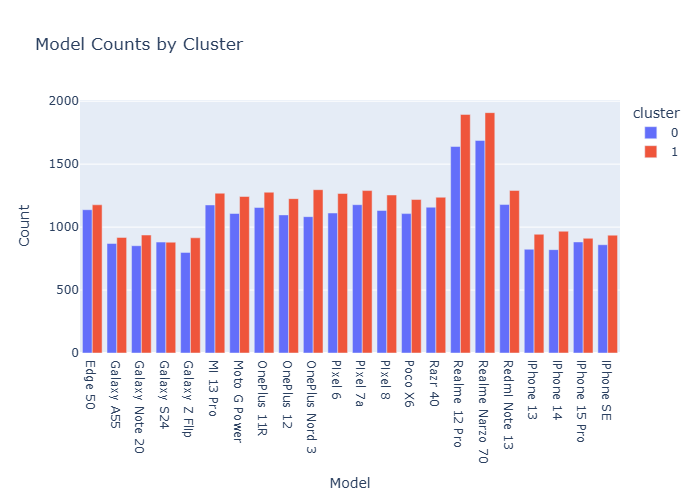

In [41]:
fig = px.bar(
    model_clusters,
    barmode="group",
    title="Model Counts by Cluster ",
    labels={"value":"Count","model":"Model","varible":"Cluster"},
)
fig.show()

In [42]:
cluster_means = df.groupby('cluster')[['performance_rating','camera_rating','helpful_votes','design_rating']].mean().reset_index()

print(cluster_means)


   cluster  performance_rating  camera_rating  helpful_votes  design_rating
0        0            1.739312       1.740702       2.333853       1.746978
1        1            3.605926       3.600899       4.828859       3.588217


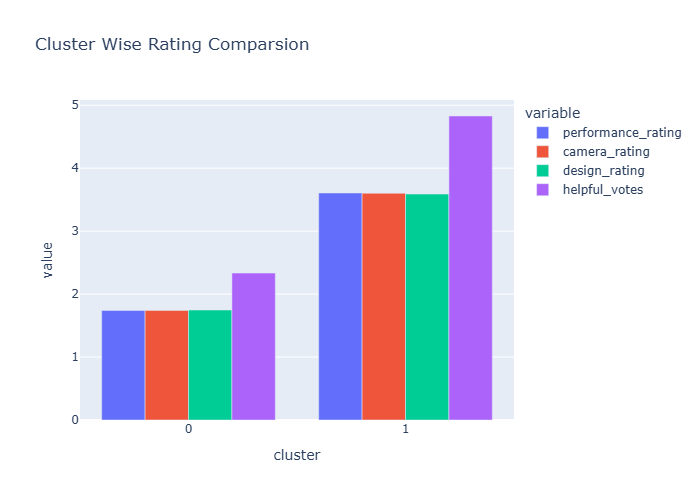

In [43]:
fig = px.bar(
    cluster_means,
    x='cluster',
    y=['performance_rating','camera_rating','design_rating','helpful_votes'],
    barmode='group',
    title='Cluster Wise Rating Comparsion'
)
fig.show()

In [44]:
negative_df = df[df['design_rating']<2.5]

print(negative_df['cluster'].value_counts())

cluster
0    18976
1     4185
Name: count, dtype: int64


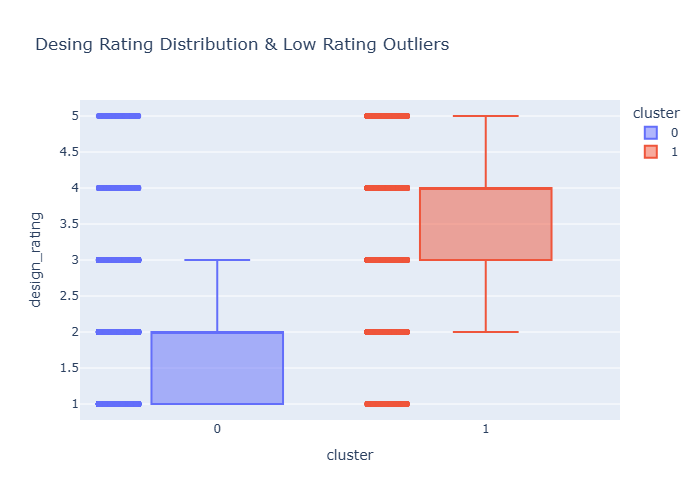

In [45]:
fig = px.box(
    df,
    x='cluster',
    y='design_rating',
    color='cluster',
    points='all',
    title='Desing Rating Distribution & Low Rating Outliers'
)
fig.show()

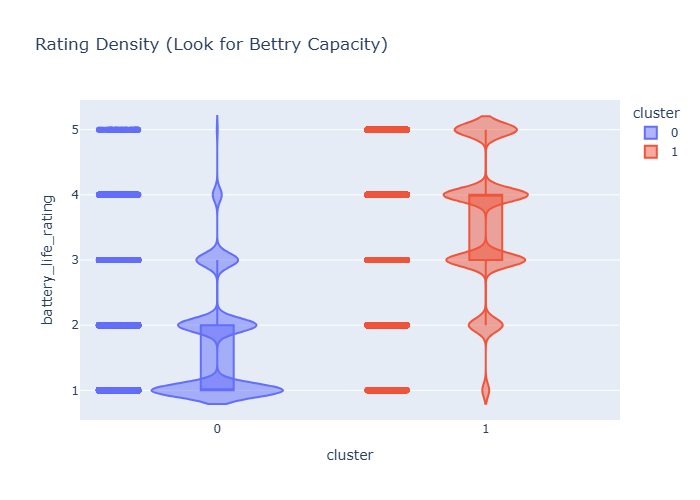

In [46]:
fig = px.violin(
    df,
    x='cluster',
    y='battery_life_rating',
    color='cluster',
    box=True,
    points='all',
    title='Rating Density (Look for Bettry Capacity)'
)
fig.show()

In [47]:
source_clusters = pd.crosstab(df["source"],df["cluster"])
print(source_clusters)

cluster        0     1
source                
Aliexpress  4654  5304
Amazon      4828  5379
Bestbuy     4608  5070
Ebay        4858  5280
Flipkart    4793  5226


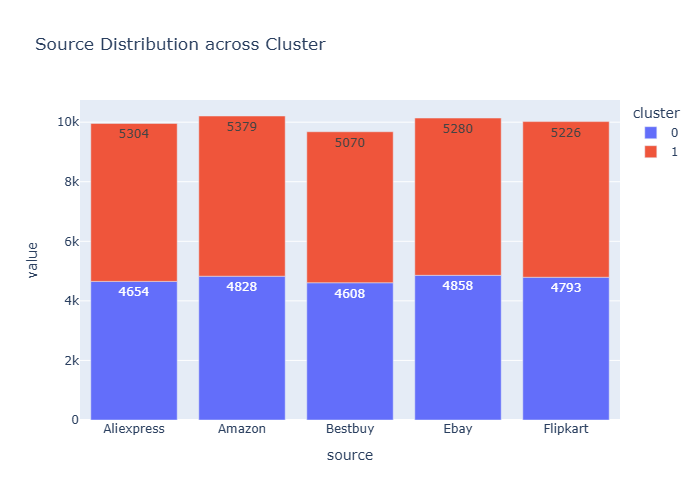

In [48]:
fig = px.bar(
    source_clusters,
    text_auto=True,
        labels=dict(x="cluster",
                    y="source",
                    color='Count'),
        title="Source Distribution across Cluster",
    )
fig.show()

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np



def get_similar_products(product_index,top_n=4):
    target_cluster = df.loc[product_index,'cluster']


    cluster_indices = df[df['cluster']==target_cluster].index

    trarget_vector = x_processed[product_index].reshape(1,-1)

    cluster_vectors = x_processed[cluster_indices]

    sim_score = cosine_similarity(trarget_vector,cluster_vectors)[0]

    top_cluster_indices = np.argsort(sim_score)


    recommeded_indicies = cluster_indices[top_cluster_indices]

    return df.loc[recommeded_indicies],sim_score[top_cluster_indices]

In [23]:
recommended_df , score = get_similar_products(1)

print(recommended_df[['brand','model','cluster']])

         brand            model  cluster
28953  Samsung       Galaxy S24        1
31111  Samsung       Galaxy A55        1
8514     Apple        iPhone 14        1
5339    Google          Pixel 6        1
10929   Google          Pixel 8        1
...        ...              ...      ...
24178   Realme    Realme 12 Pro        1
18057   Realme  Realme Narzo 70        1
37538   Realme  Realme Narzo 70        1
43243   Realme  Realme Narzo 70        1
1       Realme    Realme 12 Pro        1

[26259 rows x 3 columns]


In [24]:
import pickle

with open("x_processed.pkl","wb") as f:
    pickle.dump(x_processed,f)

In [26]:
df.to_pickle("processed_df.pkl")